In [1]:
%matplotlib inline

import torch
import matplotlib.pyplot as plt

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"

# set default torch datatype to float64
torch.set_default_dtype(torch.float64)

In [2]:
from ad_utils import (
    construct_W,
    phi_0,
    grad_phi_0,
    evaluate_phi_0s,
    evaluate_psi_0s,
    evaluate_one_forms,
    construct_quadrature,
    construct_mass_matrix,
    construct_load_vector,
    construct_delta0,
    svd_lstsq,
    NLFlux,
)

In [3]:
# problem parameters

L = 1.0  # the length of the domain
M = 50  # the number of nodes to use, including endpoints, on the fine mesh
h = L / (M - 1)  # the distance between nodes (on the fine mesh)
x_nodes = torch.linspace(0, L, M, device=DEVICE)
# the x coordinates of the nodes (on the fine mesh)
left_dir_bc = 1.0
right_dir_bc = 0.0
forcing_term = lambda x: 0 * torch.ones_like(torch.tensor(x))  # the forcing term
x_bnds = torch.tensor([0.0, L], device=DEVICE)

# the number of partitions to use, including endpoints, on the coarse mesh
Npou = 4  # this is the number of Whitney 0-forms

In [4]:
W_trainable = torch.randn(Npou - 2, M - 2, requires_grad=True, device=DEVICE)

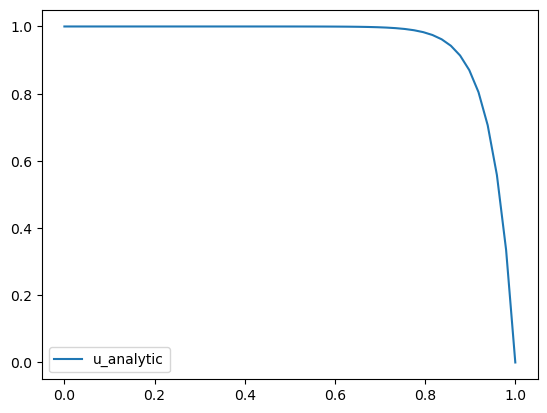

In [5]:
# just do the version without the advection term for now
# analytic solution to
# F = -eps * grad u + u, div F = 0, where u(0) = 1, u(1) = 0
x = x_nodes
eps = torch.tensor(0.05)
u_analytic = 1.0 - (1.0 - torch.exp(x / eps)) / (1.0 - torch.exp(1.0 / eps))
grad_u_analytic = (1.0 / eps) * (torch.exp(x / eps)) / (1.0 - torch.exp(1.0 / eps))
f_const = forcing_term(0.5)
plt.plot(x.cpu(), u_analytic.cpu(), label="u_analytic")
# plt.plot(x, grad_u_analytic, label="grad_u_analytic")
plt.legend()

# analytic solution to
# -u'' = f subject to u(0) = left_dir_bc and u(L) = right_dir_bc, assuming forcing_term = constant
# x = x_nodes
# f_const = forcing_term(0.5)
# a_analytic = -f_const / 2.0
# c_analytic = left_dir_bc
# b_analytic = (right_dir_bc - c_analytic - a_analytic * L**2) / L
# u_analytic = a_analytic * x**2 + b_analytic * x + c_analytic
# grad_u_analytic = 2 * a_analytic * x_bnds + b_analytic
# plt.plot(x.cpu(), u_analytic.cpu())

In [6]:
# neural network representation of the nonlinear contribution to the flux;
# this is defined on the psi bases and it takes an Npou-dimension vector (i.e., the solution in psi space)
# and outputs a num_1forms-dimension vector (i.e., the corresponding flux, in psi space)
nonlinear_flux_NN = NLFlux(Npou).to(DEVICE)

In [7]:
optimizer = torch.optim.Adam(
    [W_trainable] + list(nonlinear_flux_NN.parameters()), lr=torch.tensor(1e-3)
)

In [8]:
F_bc_left = -grad_u_analytic[0]
F_bc_right = -grad_u_analytic[-1]

psi_hat_initial = torch.randn(Npou, device=DEVICE)
psi_hat_last = psi_hat_initial.clone()

for n_epoch in range(10_000):
    W = construct_W(W_trainable)

    M0_psi = construct_mass_matrix(phi_0, phi_0, x_nodes, W=W)
    M1_psi = M1 = construct_mass_matrix(
        evaluate_one_forms,
        evaluate_one_forms,
        x_nodes,
        eval_types=["batch", "batch"],
        W=W,
    )
    delta0_psi = construct_delta0(Npou).to(DEVICE)

    A_psi = delta0_psi.T @ M1_psi @ delta0_psi

    psi_0s_bnd = evaluate_psi_0s(x_nodes, x_bnds, W)
    F_bc_vector_psi = F_bc_right * psi_0s_bnd[:, 1] - F_bc_left * psi_0s_bnd[:, 0]

    b = M0_psi @ (f_const * torch.ones(Npou, device=DEVICE)) - F_bc_vector_psi

    def F(psi_hat):
        return A_psi @ psi_hat + delta0_psi.T @ nonlinear_flux_NN(psi_hat) - b

    def F_loss(psi_hat):
        return torch.sum(F(psi_hat) ** 2)

    # nonlinear solve
    F_last = F(psi_hat_last)
    # print("    " + "{:.3e}".format(torch.norm(F_last).item()))
    for _ in range(10):
        Jac = torch.autograd.functional.jacobian(F, psi_hat_last, create_graph=True)
        if DEVICE == "cpu":
            psi_hat_next = psi_hat_last - torch.linalg.lstsq(Jac, F_last).solution
            # psi_hat_next = psi_hat_last - svd_lstsq(Jac, F_last)
        else:
            # psi_hat_next = psi_hat_last - torch.linalg.pinv(Jac) @ F_last
            psi_hat_next = psi_hat_last - svd_lstsq(Jac, F_last)
            # psi_hat_next = psi_hat_last - Jac.pinverse() @ F_last
        psi_hat_last = psi_hat_next.clone()
        F_last = F(psi_hat_last)
        if torch.norm(F_last) < 1e-10:
            break
    # print("    " + "{:.3e}".format(torch.norm(F_last).item()))

    # F_loss_last = F_loss(psi_hat_last)
    # for _ in range(10):
    #     Jac = torch.autograd.functional.jacobian(
    #         F_loss, psi_hat_last, create_graph=True
    #     )
    #     Hess = torch.autograd.functional.hessian(
    #         F_loss, psi_hat_last, create_graph=True
    #     )
    #     psi_hat_next = psi_hat_last - torch.linalg.lstsq(Hess, Jac).solution
    #     psi_hat_last = psi_hat_next.clone()
    #     F_loss_last = F_loss(psi_hat_last)

    psi_0s_on_nodes = evaluate_psi_0s(x_nodes, x_nodes, W)
    uu = psi_hat_last @ psi_0s_on_nodes

    loss = torch.sum((u_analytic - uu) ** 2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    psi_hat_last = psi_hat_last.detach()

    if n_epoch % 100 == 0:
        print(n_epoch, loss.item())

0 21.99250551478692
100 12.91431235349453
200 5.036963719609149
300 2.9633983709010767
400 2.619297835883319
500 2.4932975874605483
600 2.4210091795256927
700 2.3672528661220205
800 2.3189815123793096
900 2.2695667273278115
1000 2.2148011795696516
1100 2.151854198366472
1200 2.07915574436358
1300 1.9960106636660317
1400 1.9012197417555996
1500 1.7912823392908948
1600 1.6610014380467815
1700 1.5090288720234557
1800 1.343036951526084
1900 1.1784064311561155
2000 1.034033010103427
2100 0.9251929177600355
2200 0.8351986233162458
2300 0.7307308901261202
2400 0.5861861570089142
2500 0.3805419630961035
2600 0.1542446857484197
2700 0.03406877498843417
2800 0.005231031577560971
2900 0.0011088083246832425
3000 0.0004150405026199908
3100 0.00020296006750283855
3200 0.00010626526032915884
3300 5.6186460500259365e-05
3400 2.967389146555963e-05
3500 1.5324664402965375e-05
3600 7.693843620461219e-06
3700 3.739164025287125e-06
3800 1.7529084761210423e-06
3900 2.641205907771545e-06
4000 3.3733256058217

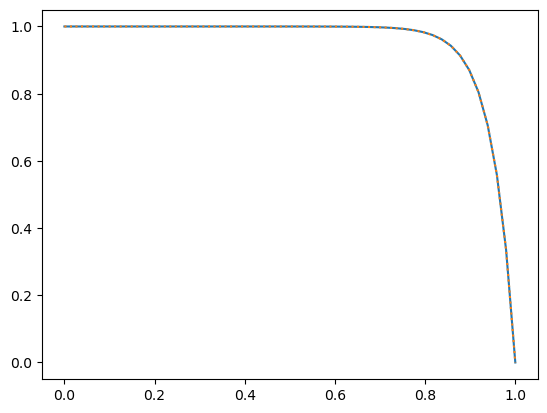

In [9]:
plt.plot(x_nodes.cpu(), uu.detach().cpu(), label="whitney")
plt.plot(x_nodes.cpu(), u_analytic.detach().cpu(), ":", label="true")

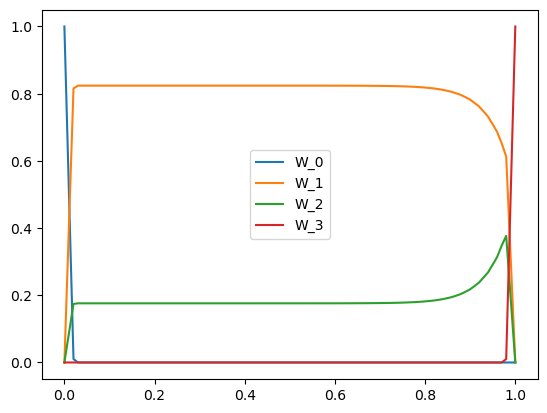

In [10]:
# evaluate and plot the W_i functions
# x, w = construct_quadrature(x_nodes, num_quad_pts=2)
x = torch.linspace(0, L, 100, device=DEVICE)
psi_0s = evaluate_psi_0s(x_nodes, x, W)
for i in range(Npou):
    plt.plot(x.cpu(), psi_0s[i].detach().cpu(), label=f"W_{i}")
plt.legend()